### Marketing ROI Analysis: Simple Linear Regression

Objective: This project analyzes a marketing dataset to identify the most effective advertising channel. We will build a Simple Linear Regression model to predict Sales and provide a data-driven, ROI-based recommendation for future budget allocation.

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

In [ ]:
# 1. Load the dataset
df = pd.read_csv(r"C:\Users\LENOVO\Desktop\Darey io\Market analysis.csv")

In [5]:
df.head(10)

,TV,Radio,Social_Media,Sales
0,16.0,6.566231,2.907983,54.732757
1,13.0,9.237765,2.409567,46.677897
2,41.0,15.886446,2.913410,150.177829
3,83.0,30.020028,6.922304,298.246340
4,15.0,8.437408,1.405998,56.594181
5,29.0,9.614382,1.027163,105.889148
6,55.0,24.893811,4.273602,198.679825
7,31.0,17.355042,2.289855,108.733932
8,76.0,24.648898,7.130116,270.189400
9,13.0,0.431128,2.229423,48.280582


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4572 entries, 0 to 4571
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   TV            4562 non-null   float64
 1   Radio         4568 non-null   float64
 2   Social_Media  4566 non-null   float64
 3   Sales         4566 non-null   float64
dtypes: float64(4)
memory usage: 143.0 KB


In [7]:
# Check what percentage of your data is actually missing
missing_percentage = df['TV'].isnull().sum() / len(df) * 100
print(f"Missing Data: {missing_percentage:.2f}%")

Missing Data: 0.22%


In [8]:
# If it's a small percentage, drop the rows with missing TV data
df_clean = df.dropna()

In [9]:
df_clean.reset_index(inplace=True, drop=True)

### Exploratory Data Analysis (EDA) & Variable Selection

Before building the model, we need to determine which independent marketing variable (TV, Radio, or Social Media) has the strongest linear relationship with our dependent variable (Sales).

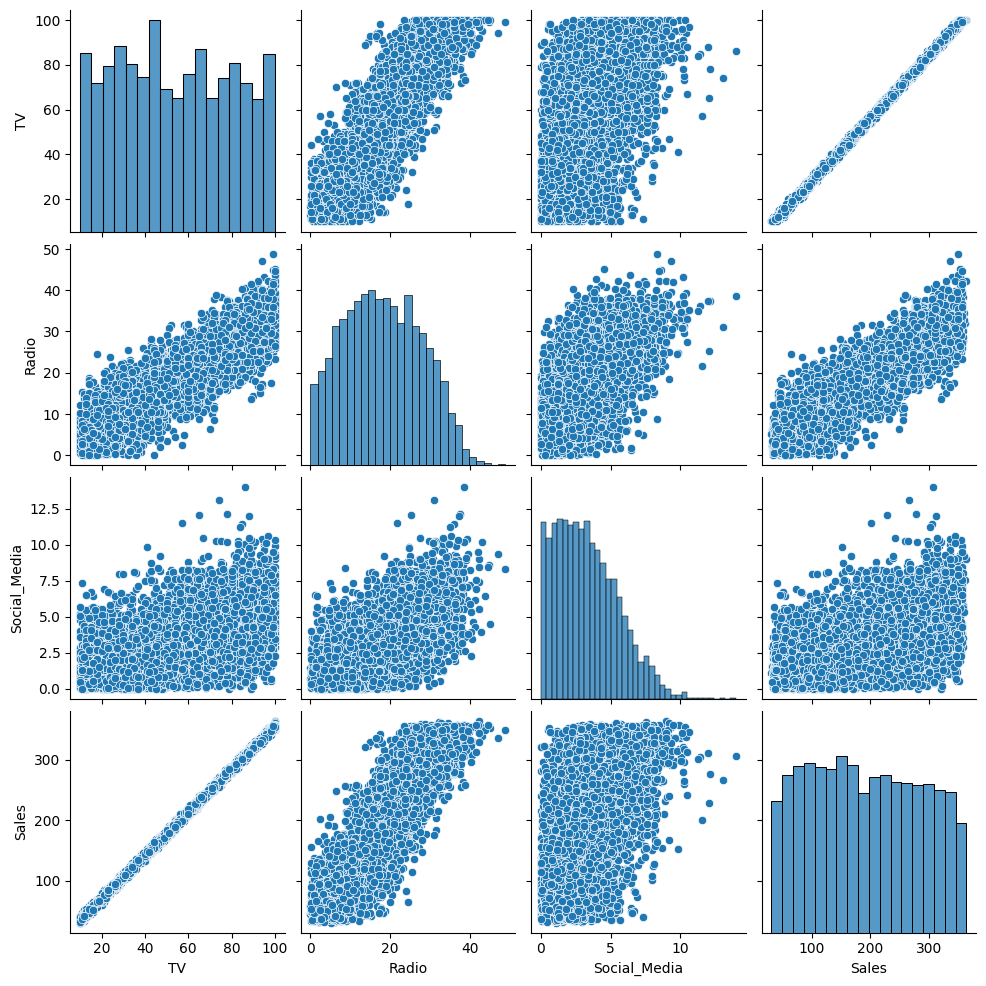

In [ ]:
# Visualize the relationships to confirm linearity visually
sns.pairplot(df_clean)

### Model Building: Ordinary Least Squares (OLS) Regression

Based on the correlation analysis, TV advertising shows the strongest relationship with Sales. We will fit an OLS regression model using TV as our independent variable.

In [ ]:
# Prepare data for OLS regression
ols_data = df_clean[['TV', 'Sales']]

In [ ]:
# Define the OLS formula
ols_formula = "Sales ~ TV"

In [13]:
from statsmodels.formula.api import ols

In [ ]:
# Fit the OLS model
OLS = ols(formula=ols_formula, data=ols_data)
model = OLS.fit()

In [ ]:
# Display the summary of the OLS model
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Sales   R-squared:                       0.999
Model:                            OLS   Adj. R-squared:                  0.999
Method:                 Least Squares   F-statistic:                 4.517e+06
Date:                Sat, 13 Jun 2026   Prob (F-statistic):               0.00
Time:                        00:43:16   Log-Likelihood:                -11366.
No. Observations:                4546   AIC:                         2.274e+04
Df Residuals:                    4544   BIC:                         2.275e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.1325      0.101     -1.317      0.188      -0.330       0.065
TV             3.5615      0.002   2125.272      0.000       3.558       3.565
==============================================================================
Omnibus:                        0.052   Durbin-Watson:                   1.998
Prob(Omnibus):                  0.974   Jarque-Bera (JB):                0.031
Skew:                          -0.001   Prob(JB):                        0.985
Kurtosis:                       3.012   Cond. No.                         138.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

### Model Validation: Diagnostic Checks

To ensure our model is statistically valid and our ROI predictions are reliable, we must test for Linearity, Homoscedasticity (equal variance), and Normality of residuals.

<Axes: xlabel='TV', ylabel='Sales'>

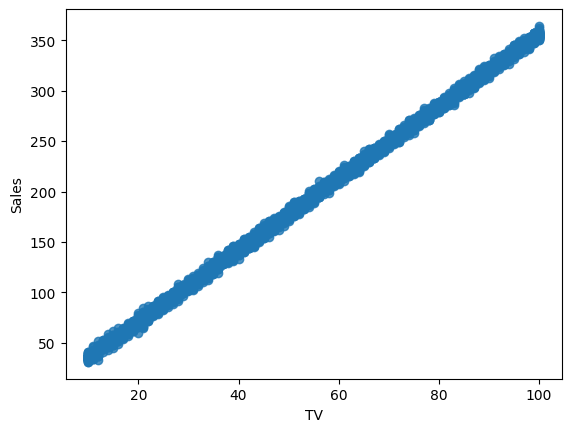

In [ ]:
# Visualize the regression line to check the Linearity
sns.regplot(x = "TV", y = "Sales", data = ols_data)

In [ ]:
# Define the independent variable
X = ols_data['TV']

In [ ]:
fitted_values = model.predict(X)

In [ ]:
residuals = model.resid

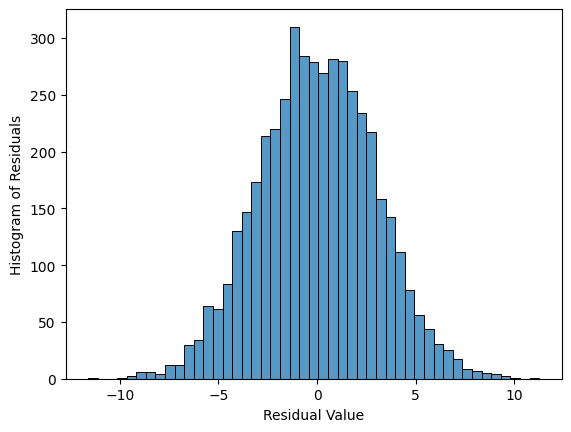

In [ ]:
# Plot the histogram of residuals to check for normality
fig = sns.histplot(residuals)
fig.set_xlabel('Residual Value')
fig.set_ylabel('Histogram of Residuals')
plt.show()

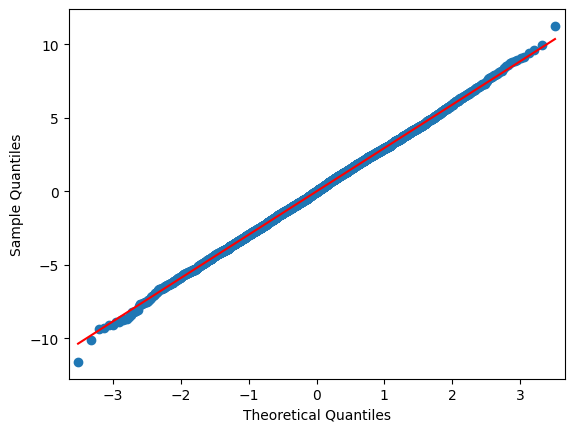

In [22]:
fig = sm.qqplot(model.resid, line = "s")
plt.show()

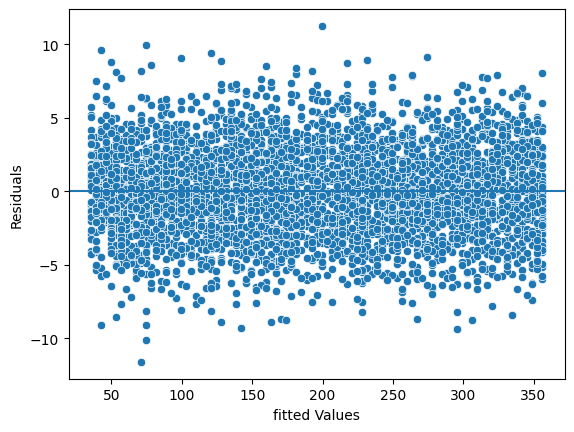

In [ ]:
# Plot the residuals against the fitted values to check for homoscedasticity
fig = sns.scatterplot(x=fitted_values, y=residuals)
fig.axhline(0)
fig.set_xlabel('fitted Values')
fig.set_ylabel('Residuals')
plt.show()

### Final Business Recommendation

After rigorous data cleaning and statistical validation, our model confirms a highly significant, nearly perfect correlation ($R^2 > 0.99$) between TV advertising spend and overall sales.The analysis proves that TV is a highly effective marketing channel. For every additional 1 unit allocated to the TV marketing budget, we project a reliable return of approximately 3.56 units in sales. Therefore, I strongly recommend prioritizing TV as the primary channel for our upcoming marketing budget allocation.